# Exploration — Analyse des films à genre unique

**Contexte :** Le dataset contient ~185 000 films avec un **seul genre**, et ~170 000 avec plusieurs genres. Dans `main.ipynb`, on utilise tous les films en prenant le premier genre listé — mais ce choix est potentiellement biaisé pour les multi-genres.

**Objectif :** Analyser ce que représentent les films à genre unique, et mesurer si le modèle performe différemment sur eux.

## Plan

1. **Caractérisation des films à genre unique** — distribution des genres, comparaison des features (rating, popularity, etc.) vs multi-genres
2. **Impact sur le modèle** — entraîner sur tous les films (stratégie actuelle) et évaluer *uniquement* sur les films à genre unique : est-ce que les performances sont meilleures ?
3. **Entraîner uniquement sur les films à genre unique** — le modèle est-il meilleur quand les labels sont non ambigus ? (au prix d'un dataset plus petit)
4. **Conclusions** — faut-il filtrer ou pondérer les films à genre unique dans notre pipeline ?

> Ce notebook informe la décision sur la stratégie de label dans `exploration/genre_label_strategy.ipynb`.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report

RANDOM_STATE = 42
SELECTED_GENRES = ['Animation', 'Horror', 'Drama']
continuous_features  = ['rating', 'total_votes', 'popularity']
passthrough_features = ['is_english', 'cast_count', 'release_month', 'release_year']
features = continuous_features + passthrough_features

In [2]:
df = pd.read_csv("hf://datasets/HenryWaltson/TMDB-IMDB-Movies-Dataset/TMDB  IMDB Movies Dataset.csv")
df = df.drop_duplicates()
df = df.drop(columns=['backdrop_path', 'keywords', 'homepage', 'tconst', 'overview', 'poster_path', 'tagline'])
df = df[df['release_date'].notna()]

# Feature engineering
total_votes = df['vote_count'] + df['numVotes']
df['rating']      = (df['vote_average'] * df['vote_count'] + df['averageRating'] * df['numVotes']) / total_votes
df['total_votes'] = total_votes
df = df.drop(columns=['vote_count', 'numVotes', 'vote_average', 'averageRating'])

df['is_english']    = (df['original_language'] == 'en').astype(int)
df['cast_count']    = df['cast'].fillna('').apply(lambda x: len(x.split(',')) if x else 0)
df['release_month'] = pd.to_datetime(df['release_date']).dt.month
df['release_year']  = pd.to_datetime(df['release_date']).dt.year

# Séparer single vs multi genre
df_with_genre = df[df['genres'].notna()].copy()
df_single = df_with_genre[~df_with_genre['genres'].str.contains(',', na=False)].copy()
df_multi  = df_with_genre[ df_with_genre['genres'].str.contains(',', na=False)].copy()

# Assigner le label (premier genre pour les deux)
df_with_genre['genre'] = df_with_genre['genres'].str.split(',').str[0].str.strip()
df_single['genre']     = df_single['genres'].str.strip()
df_multi['genre']      = df_multi['genres'].str.split(',').str[0].str.strip()

print(f"Films avec genre(s)  : {len(df_with_genre):,}")
print(f"  → Genre unique     : {len(df_single):,} ({len(df_single)/len(df_with_genre):.1%})")
print(f"  → Multi-genres     : {len(df_multi):,} ({len(df_multi)/len(df_with_genre):.1%})")

/Users/adam/Desktop/ECE/ING4/S8/Apprentissage et Estimation Bayesienne/Projet/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Films avec genre(s)  : 351,298
  → Genre unique     : 185,210 (52.7%)
  → Multi-genres     : 166,088 (47.3%)


## 1. Caractérisation des films à genre unique

Distribution des genres et comparaison des features clés entre films à genre unique et multi-genres.

/var/folders/v0/_lflz19n6hv63x17d4_zjfjm0000gn/T/ipykernel_36175/448756124.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, ax=ax, palette='Blues_r')
/var/folders/v0/_lflz19n6hv63x17d4_zjfjm0000gn/T/ipykernel_36175/448756124.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, ax=ax, palette='Blues_r')


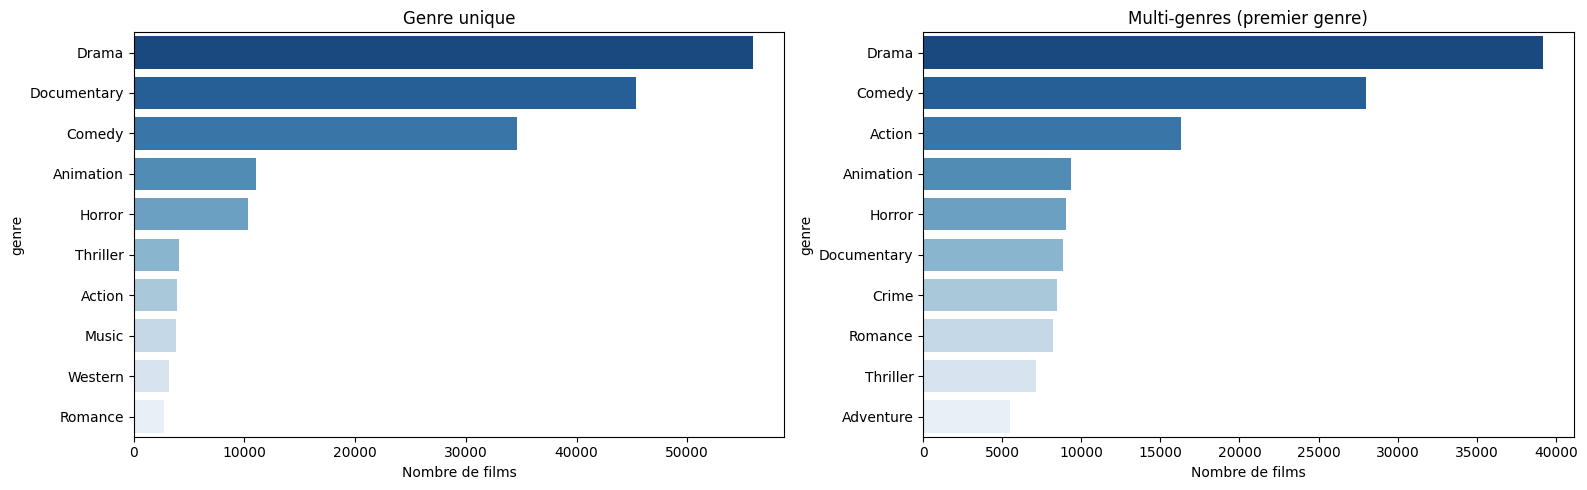

In [3]:
# Distribution des genres : single vs multi
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, df_sub, title in [
    (axes[0], df_single, "Genre unique"),
    (axes[1], df_multi,  "Multi-genres (premier genre)"),
]:
    counts = df_sub['genre'].value_counts().head(10)
    sns.barplot(x=counts.values, y=counts.index, ax=ax, palette='Blues_r')
    ax.set_title(title)
    ax.set_xlabel("Nombre de films")

plt.tight_layout()
plt.show()

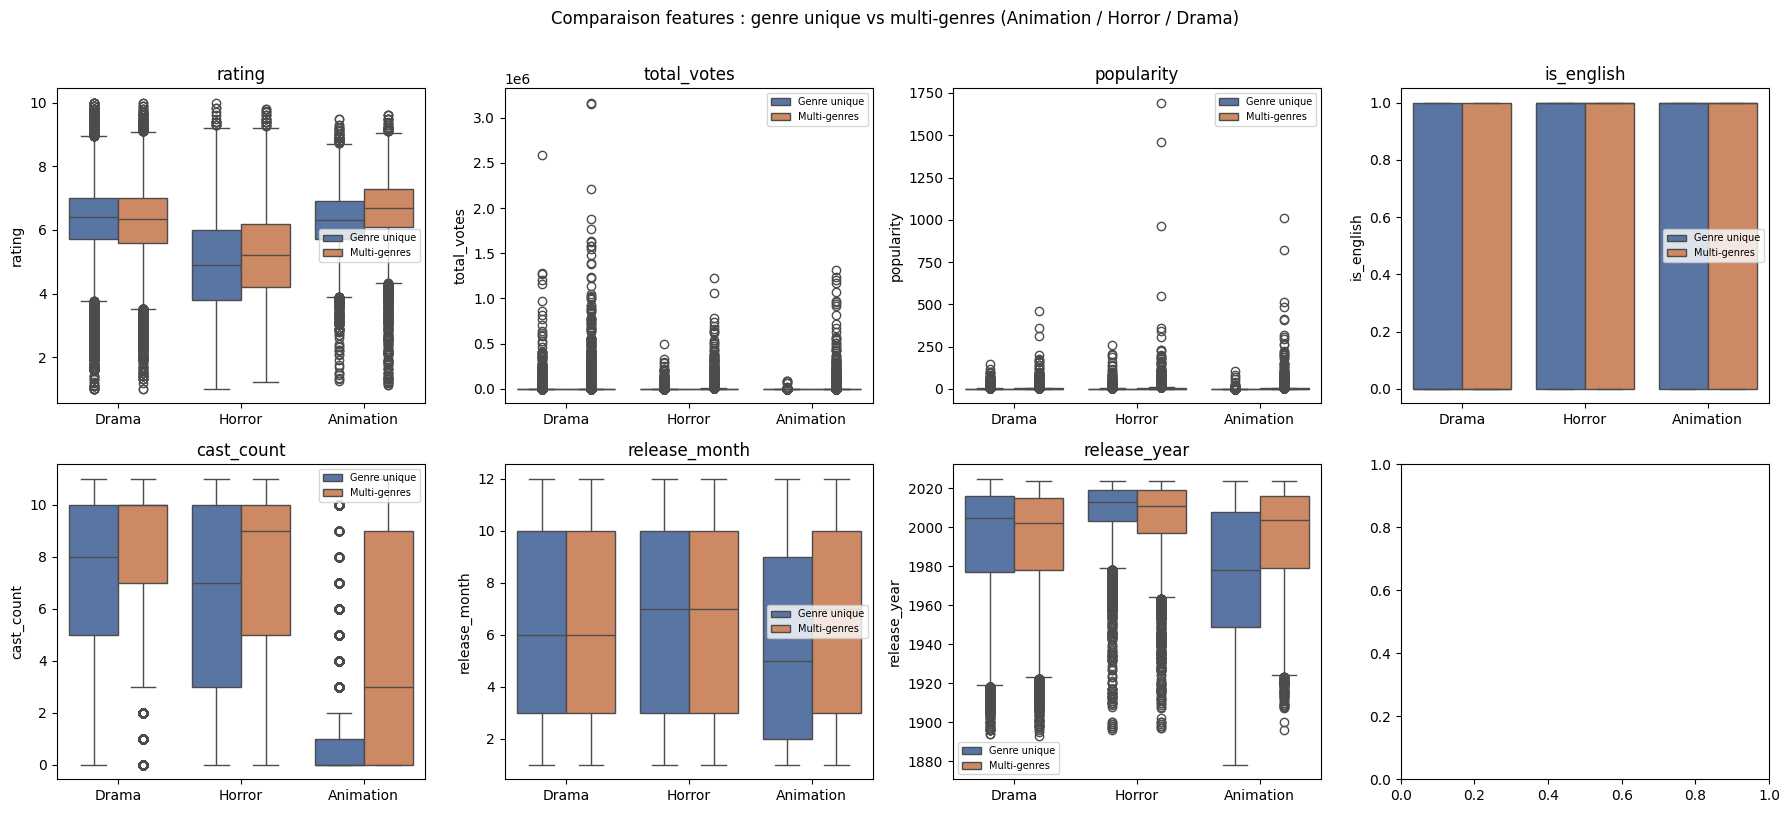


Nombre de films par groupe (nos 3 genres) :
  Genre unique : 77,384
  Multi-genres : 57,550


In [4]:
# Comparaison des features clés : single vs multi (sur nos 3 genres)
df_single_3 = df_single[df_single['genre'].isin(SELECTED_GENRES)][features + ['genre']].copy()
df_multi_3  = df_multi[ df_multi['genre'].isin(SELECTED_GENRES)][features + ['genre']].copy()
df_single_3['source'] = 'Genre unique'
df_multi_3['source']  = 'Multi-genres'
df_compare = pd.concat([df_single_3, df_multi_3])

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.boxplot(data=df_compare, x='genre', y=feat, hue='source',
                ax=axes[i], palette=['#4C72B0', '#DD8452'])
    axes[i].set_title(feat)
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=7)

plt.suptitle("Comparaison features : genre unique vs multi-genres (Animation / Horror / Drama)", y=1.01)
plt.tight_layout()
plt.show()

print("\nNombre de films par groupe (nos 3 genres) :")
print(f"  Genre unique : {len(df_single_3):,}")
print(f"  Multi-genres : {len(df_multi_3):,}")

## 2. Impact sur le modèle — évaluer sur genre unique seulement

On entraîne sur **tous les films** (stratégie actuelle, avec undersampling), puis on évalue séparément sur les films à genre unique et les multi-genres. Cela révèle si le modèle performe mieux sur des labels non ambigus.

In [5]:
def make_pipeline():
    preprocessor = ColumnTransformer([
        ('scale', RobustScaler(), continuous_features),
        ('pass',  'passthrough',  passthrough_features)
    ])
    return Pipeline([('preprocessor', preprocessor), ('model', GaussianNB())])

# Entraînement sur tous les films (undersampling, stratégie actuelle)
df_all = df_with_genre[df_with_genre['genre'].isin(SELECTED_GENRES)].copy()
cap = df_all['genre'].value_counts().min()
df_balanced = df_all.groupby('genre', group_keys=False).sample(n=cap, random_state=RANDOM_STATE)

pipe = make_pipeline()
pipe.fit(df_balanced[features], df_balanced['genre'])

# Évaluation sur genre unique (nos 3 genres, sans undersampling)
test_single = df_single_3.dropna(subset=features)
test_multi  = df_multi_3.dropna(subset=features)

print("=== Évaluation sur films à GENRE UNIQUE ===")
print(classification_report(test_single['genre'], pipe.predict(test_single[features])))

print("=== Évaluation sur films MULTI-GENRES ===")
print(classification_report(test_multi['genre'], pipe.predict(test_multi[features])))

=== Évaluation sur films à GENRE UNIQUE ===
              precision    recall  f1-score   support

   Animation       0.50      0.88      0.64     11059
       Drama       0.92      0.77      0.84     55972
      Horror       0.52      0.55      0.53     10353

    accuracy                           0.75     77384
   macro avg       0.64      0.73      0.67     77384
weighted avg       0.80      0.75      0.77     77384

=== Évaluation sur films MULTI-GENRES ===
              precision    recall  f1-score   support

   Animation       0.51      0.54      0.53      9323
       Drama       0.82      0.76      0.79     39179
      Horror       0.39      0.51      0.45      9048

    accuracy                           0.68     57550
   macro avg       0.58      0.60      0.59     57550
weighted avg       0.70      0.68      0.69     57550



## 3. Entraîner uniquement sur les films à genre unique

On réduit le dataset aux films dont le label est non ambigu. Le dataset sera plus petit mais plus propre — est-ce que ça améliore les performances ?

In [6]:
df_single_final = df_single[df_single['genre'].isin(SELECTED_GENRES)].copy()

cap_single = df_single_final['genre'].value_counts().min()
df_single_balanced = df_single_final.groupby('genre', group_keys=False).sample(n=cap_single, random_state=RANDOM_STATE)

print("Distribution après undersampling (genre unique seulement) :")
print(df_single_balanced['genre'].value_counts())
print(f"Total : {len(df_single_balanced):,} films (vs {len(df_balanced):,} avec tous les films)\n")

X_tr, X_te, y_tr, y_te = train_test_split(
    df_single_balanced[features], df_single_balanced['genre'],
    test_size=0.2, stratify=df_single_balanced['genre'], random_state=RANDOM_STATE
)

pipe_single = make_pipeline()
pipe_single.fit(X_tr, y_tr)

print("=== Modèle entraîné sur genre unique seulement ===")
print(classification_report(y_te, pipe_single.predict(X_te)))

print("=== Rappel : modèle entraîné sur tous les films ===")
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    df_balanced[features], df_balanced['genre'],
    test_size=0.2, stratify=df_balanced['genre'], random_state=RANDOM_STATE
)
pipe2 = make_pipeline()
pipe2.fit(X_tr2, y_tr2)
print(classification_report(y_te2, pipe2.predict(X_te2)))

Distribution après undersampling (genre unique seulement) :
genre
Animation    10353
Drama        10353
Horror       10353
Name: count, dtype: int64
Total : 31,059 films (vs 58,203 avec tous les films)

=== Modèle entraîné sur genre unique seulement ===
              precision    recall  f1-score   support

   Animation       0.60      0.94      0.73      2070
       Drama       0.73      0.59      0.65      2071
      Horror       0.80      0.50      0.62      2071

    accuracy                           0.68      6212
   macro avg       0.71      0.68      0.67      6212
weighted avg       0.71      0.68      0.67      6212

=== Rappel : modèle entraîné sur tous les films ===
              precision    recall  f1-score   support

   Animation       0.73      0.73      0.73      3880
       Drama       0.60      0.72      0.66      3880
      Horror       0.71      0.57      0.63      3881

    accuracy                           0.67     11641
   macro avg       0.68      0.67      0.

## 4. Conclusions

### Données (section 1)
- Le dataset est quasiment équilibré : **52.7% genre unique** (185k) vs 47.3% multi-genres (166k)
- Sur nos 3 genres retenus : 77k films à genre unique vs 57k multi-genres

### Le modèle performe mieux sur les films à genre unique (section 2)

On entraîne sur tous les films (stratégie actuelle), et on évalue séparément :

| Population testée | Anim F1 | Drama F1 | Horror F1 | Macro F1 | Acc |
|---|---|---|---|---|---|
| Genre unique | 0.64 | **0.84** | 0.53 | **0.67** | **75%** |
| Multi-genres | 0.53 | 0.79 | 0.45 | 0.59 | 68% |

→ Le modèle est **nettement meilleur sur les films à genre unique** (+8 points d'accuracy, +8 points Macro F1). C'est cohérent : ces films ont un label non ambigu, donc le signal est plus propre.

→ Drama bénéficie le plus de la clarté du label (F1 0.84 vs 0.79). Horror reste difficile dans les deux cas.

> ⚠️ **Attention à l'interprétation** : ces évaluations sont déséquilibrées (Drama domine largement dans les deux populations), donc le weighted F1 est tiré vers Drama. Le Macro F1 est plus représentatif.

### Entraîner uniquement sur genre unique (section 3)

| Stratégie d'entraînement | Anim F1 | Drama F1 | Horror F1 | Macro F1 | Acc |
|---|---|---|---|---|---|
| Tous les films (58k) | 0.73 | 0.66 | **0.63** | **0.67** | **67%** |
| Genre unique seulement (31k) | **0.73** | 0.65 | 0.62 | **0.67** | 68% |

→ Les deux stratégies donnent **le même Macro F1 (0.67)**, malgré deux fois moins de données. Le modèle entraîné sur genre unique a une meilleure précision sur Animation et Horror, mais un moins bon recall.

→ **Réduire à genre unique seul ne dégrade pas le modèle**, mais n'améliore pas non plus de façon significative.

### Décision pour `genre_label_strategy.ipynb`

- Les films à genre unique sont des **données plus fiables** (label non ambigu)
- Entraîner uniquement sur eux ne change pas les performances globales
- La vraie question reste : **comment assigner un label aux multi-genres** ? Le premier genre est-il le bon ? → à explorer dans `genre_label_strategy.ipynb`
- Piste à tester : entraîner sur genre unique, et évaluer si une autre stratégie de label pour les multi-genres améliore le modèle